# SentimentumAI — Documentación Sprint 1
**Análisis de Sentimientos de Odio en Twitter/X**

---

## Equipo de Trabajo

| Nombre | Rol | Responsabilidad |
|--------|-----|-----------------|
| Héctor Ramón Jiménez Esquivel | Product Owner | Representa la voz del cliente. Gestiona, detalla y prioriza el Product Backlog para maximizar el ROI. Define el alcance y valida incrementos en la Sprint Review. |
| Nikesha Sonalhy Mercado Escoto | Scrum Master | Líder servicial y coach. Asegura la correcta ejecución de Scrum, facilita eventos (Daily, Planning, Review, Retrospective), protege al equipo y resuelve impedimentos. |
| Carlo Eugenio Leviaguirre Chavez | Scrum Team (Dev Team) | Grupo autoorganizado. Deciden técnicamente cómo resolver el problema, ejecutan tareas, aseguran la calidad técnica y entregan un incremento utilizable por Sprint. |
| Denisse Martínez Ruíz | Scrum Team (Dev Team) | Grupo autoorganizado. Deciden técnicamente cómo resolver el problema, ejecutan tareas, aseguran la calidad técnica y entregan un incremento utilizable por Sprint. |

---

## Información del Sprint

| Campo | Valor |
|-------|-------|
| Sprint | 1 |
| Fecha de inicio | 1 de junio de 2026 |
| Fecha de cierre | 14 de junio de 2026 |
| Total Story Points | 19 |

---

## Objetivo del Sprint

> Establecer el entorno tecnológico del proyecto, importar y explorar el dataset de Twitter/X, ejecutar el pipeline completo de preprocesamiento de lenguaje natural (limpieza, normalización y vectorización TF-IDF) y obtener una matriz de texto limpia y balanceada lista para el entrenamiento de modelos clasificadores.

---

## Historias de Usuario del Sprint 1

| ID | Historia | Story Points | Prioridad | Fecha objetivo | Estado |
|----|----------|-------------|-----------|----------------|--------|
| HU-01 | Importación y exploración del dataset | 3 | Must Have | 2 jun | ✅ Completada |
| HU-02 | Limpieza y normalización de texto | 5 | Must Have | 5 jun | ⬜ Pendiente |
| HU-03 | Análisis de distribución de clases | 3 | Must Have | 3 jun | ⬜ Pendiente |
| HU-04 | Vectorización TF-IDF | 5 | Must Have | 10 jun | ⬜ Pendiente |
| HU-05 | WordClouds y análisis léxico | 3 | Should Have | 12 jun | ⬜ Pendiente |

---

## HU-01 — Importación y Exploración del Dataset

**Como** investigador social, **quiero** que el sistema importe el dataset de Twitter/X y muestre estadísticas básicas, **para** entender la estructura, volumen y calidad de los datos antes de procesarlos.

### Dataset utilizado

- **Archivo:** `twitter_train.csv`
- **Fuente:** Kaggle — Twitter Hate Speech Dataset
- **Columnas:** `id`, `label`, `tweet`
- **Total de registros:** 31,192 tweets

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

___
### Carga del Dataset

In [4]:
df_twitter = pd.read_csv("Datos/twitter_train.csv")

___
### Exploración básica

In [5]:
display(df_twitter.head(3))

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty


In [6]:
print(df_twitter.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None


In [7]:
print(df_twitter.describe().T)

         count          mean          std  ...      50%       75%      max
id     31962.0  15981.500000  9226.778988  ...  15981.5  23971.75  31962.0
label  31962.0      0.070146     0.255397  ...      0.0      0.00      1.0

[2 rows x 8 columns]


In [8]:
print(f"Columnas totales del dataset: {df_twitter.shape[0]}")
print(f"Filas totales del dataset: {df_twitter.shape[1]}")

Columnas totales del dataset: 31962
Filas totales del dataset: 3


In [9]:
print("=== TIPOS DE DATOS ===")
print(df_twitter.dtypes)

=== TIPOS DE DATOS ===
id        int64
label     int64
tweet    object
dtype: object


In [10]:
print("=== ANÁLISIS DE NULOS Y DUPLICADOS ===")
print(F"Total de nulos: \n{df_twitter.isnull().sum()}")
print(f"Total de duplicados: {df_twitter.duplicated().sum()}")

=== ANÁLISIS DE NULOS Y DUPLICADOS ===
Total de nulos: 
id       0
label    0
tweet    0
dtype: int64
Total de duplicados: 0


In [11]:
print("=== ANÁLISIS DE DISTRIBUCIÓN DE CLASES ===")
print("Distribución por conteo")
print(df_twitter["label"].value_counts())
print("Distribución por porcentaje")
print(df_twitter["label"].value_counts(normalize=True)*100)

=== ANÁLISIS DE DISTRIBUCIÓN DE CLASES ===
Distribución por conteo
label
0    29720
1     2242
Name: count, dtype: int64
Distribución por porcentaje
label
0    92.98542
1     7.01458
Name: proportion, dtype: float64


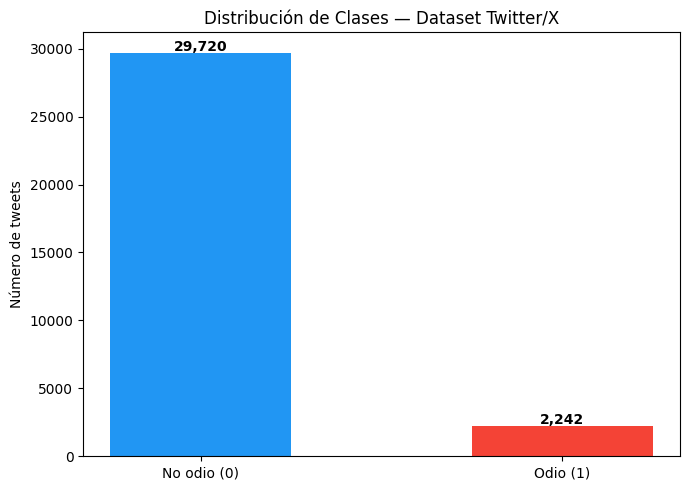

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

conteo = df_twitter["label"].value_counts()
colores = ['#2196F3', '#F44336']
etiquetas = ['No odio (0)', 'Odio (1)']
barras = ax.bar(etiquetas, conteo.values, color= colores, width= 0.5)

for barra, valor in zip(barras, conteo.values):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 100,
            f'{valor:,}', ha='center', fontweight='bold')

ax.set_title('Distribución de Clases — Dataset Twitter/X')
ax.set_ylabel('Número de tweets')
plt.tight_layout()
plt.savefig('outputs/distribucion_clases.png', dpi=150)
plt.show()

Se observa un desbalance importante, con un total del **93% no odio vs un 7% odio**. Esto es relevante ya qye los modelos tienden a ignorar la clase minoritaria. 

Se deberá considerar una estratégia de balanceo en futuros pasos.


### Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| Total de tweets | 31,962 |
| Columnas | 3 (`id`, `label`, `tweet`) |
| Valores nulos | 0 |
| Tweets duplicados | 0 |
| Tweets sin odio (label=0) | 29,720 (92.99%) |
| Tweets de odio (label=1) | 2,242 (7.01%) |

### Criterios de Aceptación

- [x] El dataset se carga correctamente desde archivo CSV
- [x] Se visualizan las primeras filas, tipos de datos y dimensiones del DataFrame
- [x] Se reporta el número total de tweets y la distribución inicial de etiquetas
- [x] Se identifican valores nulos o duplicados

### Hallazgos Clave

> **Desbalance de clases:** El dataset presenta un desbalance significativo con una proporción de 13:1 entre tweets sin odio y tweets de odio (92.99% vs 7.01%), superando el umbral crítico de 3:1. Se requerirá una estrategia de balanceo antes del entrenamiento (oversampling, undersampling o ajuste de `class_weight`). Esto se aborda en HU-03.

---

## HU-02 — Limpieza y Normalización de Texto

**Como** desarrollador del equipo, **quiero** aplicar un pipeline de limpieza al campo `tweet`, **para** eliminar ruido textual y mejorar la calidad de los datos de entrada al modelo.

In [13]:
# ============================================================
# SentimentumAI — HU-02: Limpieza y normalización de texto
# Equipo: Carlo Leviaguirre, Denisse Martínez
# Sprint 1 | Semana 1
# ============================================================
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [14]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    #Normalizamos el texto a minúsculas
    text = text.lower()
    #A través de funciones regex eliminamos URLS
    text = re.sub(r'http\S+|www\S+', '', text)
    #A través de funciones regex eliminamos mencinoes
    text = re.sub(r'@\w+','', text)
    #A través de funciones regex eliminamos hashtags 
    text = re.sub(r'#\w+', '', text)
    # Eliminamos caracteres especiales y números
    text = re.sub(r'[^a-z ]', '', text)
    # Tokenizamos, eliminamos stopwords y lematizamos
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

In [15]:
df_twitter['clean_tweet'] = df_twitter['tweet'].apply(clean_text)
display(df_twitter[['tweet', 'clean_tweet']].head(10))

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunction
1,@user @user thanks for #lyft credit i can't us...,thanks credit cant use cause dont offer wheelc...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,love u take u time ur
4,factsguide: society now #motivation,factsguide society
5,[2/2] huge fan fare and big talking before the...,huge fan fare big talking leave chaos pay disp...
6,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,the next school year is the year for exams.ð...,next school year year exam cant think
8,we won!!! love the land!!! #allin #cavs #champ...,love land
9,@user @user welcome here ! i'm it's so #gr...,welcome im


In [16]:
#Verificación de nulos o blancos 

In [17]:
tweets_vacios = df_twitter[(df_twitter['clean_tweet'].str.strip() == '') | (df_twitter['clean_tweet'].isna())].shape[0]
print(f"El total de tweets vacios después de la limpieza: {tweets_vacios}")
print(f"El porcentaje es: {tweets_vacios/len(df_twitter)*100:.2f}%")

El total de tweets vacios después de la limpieza: 452
El porcentaje es: 1.41%


In [18]:
df_twitter = df_twitter[(df_twitter['clean_tweet'].str.strip() != '') & (df_twitter['clean_tweet'].notna())]
print(f"Total de tweets después de limpieza: {df_twitter.shape[0]}")

Total de tweets después de limpieza: 31510


### Decisiones Técnicas

> **Lematización sobre Stemming:** Se eligió `WordNetLemmatizer` en lugar de `PorterStemmer` porque la lematización devuelve la forma correcta del diccionario, preservando el significado de palabras clave relacionadas con discurso de odio. El stemming puede distorsionar palabras críticas para el análisis (ej. "hate" → "hat").

> **Pipeline clásico sobre Transformers:** Se evaluó el uso de Hugging Face Transformers para mejor comprensión de contexto y sarcasmo. Se descartó para Sprint 1 por ser inconsistente con el roadmap definido (Bloque B: TF-IDF). Los transformers se integrarán en Sprint 2 como mejora comparativa sobre el baseline.


## Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| Total original | 31,962 tweets |
| Tweets vacíos post-limpieza | 452 (1.41%) |
| Tweets con texto válido | 31,510 (98.59%) |
| Criterio mínimo requerido | 95% |

### Criterios de Aceptación

- [x] Se eliminan URLs, menciones, hashtags, caracteres especiales y números
- [x] Se convierte el texto a minúsculas
- [x] Se aplica tokenización y eliminación de stopwords en inglés
- [x] Se aplica lematización con `WordNetLemmatizer`
- [x] Se crea la columna `clean_tweet` con el texto procesado
- [x] Al menos el 95% de los tweets tienen texto limpio no vacío (resultado: 98.59%)

---

## Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| Total original | 31,962 tweets |
| Tweets vacíos post-limpieza | 452 (1.41%) |
| Tweets con texto válido | 31,510 (98.59%) |
| Criterio mínimo requerido | 95% |

### Criterios de Aceptación

- [x] Se eliminan URLs, menciones, hashtags, caracteres especiales y números
- [x] Se convierte el texto a minúsculas
- [x] Se aplica tokenización y eliminación de stopwords en inglés
- [x] Se aplica lematización con `WordNetLemmatizer`
- [x] Se crea la columna `clean_tweet` con el texto procesado
- [x] Al menos el 95% de los tweets tienen texto limpio no vacío (resultado: 98.59%)

---

## HU-03 — Análisis de  distribución de clases

**Como** analista de datos, **quiero** visualizar la distribución de clases del dataset, **para** identificar desbalance y decidir si se requiere técnica de balanceo antes del entrenamiento. 

In [19]:
conteo = df_twitter['label'].value_counts()
porcentaje = df_twitter['label'].value_counts(normalize=True) * 100
ratio = conteo[0] / conteo[1]

print("=== ANÁLISIS DE DISTRIBUCIÓN DE CLASES ===")
print(f"No odio (0): {conteo[0]:,} tweets ({porcentaje[0]:.2f}%)")
print(f"Odio    (1): {conteo[1]:,} tweets ({porcentaje[1]:.2f}%)")
print(f"Ratio desbalance: {ratio:.1f}:1")

=== ANÁLISIS DE DISTRIBUCIÓN DE CLASES ===
No odio (0): 29,277 tweets (92.91%)
Odio    (1): 2,233 tweets (7.09%)
Ratio desbalance: 13.1:1


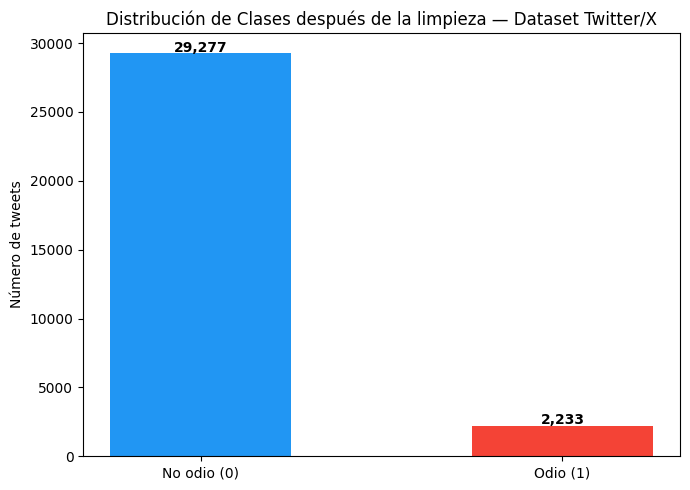

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

conteo = df_twitter["label"].value_counts()
colores = ['#2196F3', '#F44336']
etiquetas = ['No odio (0)', 'Odio (1)']
barras = ax.bar(etiquetas, conteo.values, color= colores, width= 0.5)

for barra, valor in zip(barras, conteo.values):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 100,
            f'{valor:,}', ha='center', fontweight='bold')

ax.set_title('Distribución de Clases después de la limpieza — Dataset Twitter/X')
ax.set_ylabel('Número de tweets')
plt.tight_layout()
plt.savefig('outputs/distribucion_clases.png', dpi=150)
plt.show()

### Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| No odio (label=0) | 29,277 tweets (92.91%) |
| Odio (label=1) | 2,233 tweets (7.09%) |
| Ratio de desbalance | 13.1:1 |
| Umbral crítico | 3:1 |

### Estrategia de Balanceo

Se evaluaron tres estrategias:

| Estrategia | Descripción | Decisión |
|------------|-------------|----------|
| Undersampling | Reduce tweets de clase 0 | ❌ Descartada — pérdida significativa de información con solo 2,233 tweets de odio |
| Oversampling (SMOTE) | Genera tweets sintéticos de clase 1 | ❌ Descartada — puede generar texto poco realista que sesgue el modelo |
| `class_weight='balanced'` | Penaliza más los errores en clase minoritaria | ✅ Seleccionada — trabaja con datos reales sin modificar el dataset |

> **Decisión del equipo:** Se aplicará `class_weight='balanced'` directamente en el clasificador durante HU-04, lo que instruye al modelo a dar mayor peso a los errores en tweets de odio sin alterar la distribución real del dataset.

### Criterios de Aceptación

- [x] Se genera gráfico de barras con conteo por clase
- [x] Se calcula el porcentaje de tweets por clase
- [x] Se documenta el desbalance (ratio 13.1:1, supera el umbral de 3:1)
- [x] Se propone estrategia de corrección: `class_weight='balanced'`


## HU-04 — Vectorización TF-IDF / CountVectorize

**Como** desarrollador del equipo, **quiero* transformar el texto limpio en una matriz numérica mediante TF-IDF, **para** que los clasificadores de Machine Learning puedan procesar los datos.

### Concepto

TF-IDF (Term Frequency - Inverse Document Frequency) convierte cada tweet en un vector numérico donde cada palabra del vocabulario obtiene un puntaje:

- **TF** — qué tan seguido aparece la palabra dentro de un tweet específico
- **IDF** — qué tan rara es esa palabra en todo el dataset
- **TF-IDF = TF × IDF** — alto cuando una palabra es frecuente en un tweet pero rara en el resto del dataset

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np 


#Separamos el df en train y test aplicando 80 - train y 20 - test
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_twitter['clean_tweet'],
    df_twitter['label'],
    test_size = 0.2, 
    random_state = 42,
    stratify = df_twitter['label']
)

#creamos el vectorizador y aplicamos sobre X_train_text
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_text)

#Vocabulario aprendido
print(f"Tamaño del vocabulario: {len(vectorizer.vocabulary_)}")
print(f"Primeras 20 palabras del vocabulario: {list(vectorizer.vocabulary_.keys())[:20]}")

#Dimensiones y dispersión de la matriz
print(f"\nDispersiones X_train: {X_train.shape}")
print(f"Tipo de matriz: {type(X_train)}")
print(f"Porcentaje de 0's: {(1 - X_train.nnz / (X_train.shape[0]*X_train.shape[1]))*100:.2f}%")

#Palabras con mayor peso TF - IDF promedio 
promedios = np.asarray(X_train.mean(axis= 0)).flatten()
top_idx = promedios.argsort()[-10:][::-1]
features = vectorizer.get_feature_names_out()
print("Top 10 de palabras con mayor peso para TF - IDF ")
for i in top_idx:
    print(f"{features[i]}: {promedios[i]:.4f}")

Tamaño del vocabulario: 5000
Primeras 20 palabras del vocabulario: ['good', 'morning', 'pick', 'box', 'please', 'real', 'super', 'excited', 'almost', 'time', 'year', 'attack', 'bull', 'game', 'really', 'think', 'head', 'empty', 'around', 'city']

Dispersiones X_train: (25208, 5000)
Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>
Porcentaje de 0's: 99.91%
Top 10 de palabras con mayor peso para TF - IDF 
day: 0.0243
happy: 0.0177
love: 0.0157
time: 0.0132
amp: 0.0128
im: 0.0120
today: 0.0108
father: 0.0095
like: 0.0094
get: 0.0093


In [22]:
X_test = vectorizer.transform(X_test_text)
print(f"Dimensiones X_test: {X_test.shape}")

Dimensiones X_test: (6302, 5000)


### Decisiones Técnicas

> **Split antes de vectorizar:** Se separó train/test sobre el texto limpio (`clean_tweet`) **antes** de aplicar `fit_transform`, para evitar *data leakage*. El vectorizador aprende el vocabulario únicamente con `X_train_text` y luego se aplica `transform` (sin `fit`) sobre `X_test_text`.

> **Estratificación:** Se usó `stratify=df_twitter['label']` para mantener la proporción 92.91%/7.09% (documentada en HU-03) tanto en train como en test.

### Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| Tamaño del vocabulario | 5,000 |
| Dimensiones X_train | (25,208, 5,000) — 80% |
| Dimensiones X_test | (6,302, 5,000) — 20% |
| Total | 31,510 tweets ✅ |
| Sparsity de X_train | 99.91% |

### Hallazgos del QA

> **Dominancia de la clase mayoritaria:** El top 10 de palabras con mayor peso TF-IDF promedio (`day`, `happy`, `love`, `time`, `amp`, `im`, `today`, `father`, `like`, `get`) refleja vocabulario neutral/positivo, no asociado a discurso de odio. Esto se debe a que el promedio se calcula sobre todo `X_train`, donde el 92.91% son tweets sin odio. Para identificar vocabulario asociado específicamente al odio se requiere comparar promedios TF-IDF separados por clase (label=0 vs label=1) — análisis que se realizará en HU-05 (Sprint 2).

> **Artefacto de limpieza "amp":** La palabra `amp` apareció en el top 10, pero no es una palabra real — es un residuo de la entidad HTML `&amp;` (forma codificada de "&" en Twitter). Al eliminar `&` y `;` durante la limpieza (HU-02), queda el fragmento "amp" suelto. Se documenta como hallazgo para una posible mejora futura en la función `clean_text()`.

### Criterios de Aceptación

- [x] Se aplica `TfidfVectorizer` sobre `clean_tweet`
- [x] El vocabulario se limita a los 5,000 términos más frecuentes
- [x] Se genera la matriz de features X y el vector de etiquetas y
- [x] Se divide el dataset en train (80%) y test (20%) con `train_test_split` estratificado
- [x] Se verifica la dimensión final de X_train y X_test


## HU-05 — WordClouds y análisis léxico

**Como** activista de derechos humanos, **quiero** visualizar las palabras más frecuentes en tweets de odio vs. tweets neutros, **para** identificar patrones léxicos del discurso agresivo.

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_odio = ''.join(df_twitter[df_twitter['label'] == 1]['clean_tweet'])
texto_no_odio = ''.join(df_twitter[df_twitter['label'] == 0]['clean_tweet'])

print(f"Las palabras totales en tweets de odio: {len(texto_odio.split())}")
print(f"las palabras totales en tweets de no odio: {len(texto_no_odio.split())}")

Las palabras totales en tweets de odio: 11387
las palabras totales en tweets de no odio: 133363


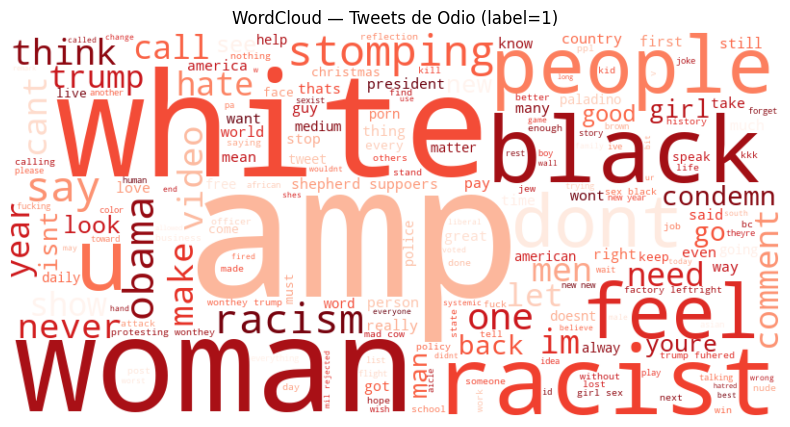

In [24]:
wordcloud_odio = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_odio)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_odio, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Tweets de Odio (label=1)')
plt.savefig('outputs/wordcloud_odio.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgo y Refinamiento del Pipeline

Durante la generación de la primera WordCloud de tweets de odio se detectaron tres tipos de ruido léxico que no habían sido filtrados en HU-02:

| Hallazgo | Causa | Ejemplo |
|----------|-------|---------|
| Artefacto "amp" | Residuo de la entidad HTML `&amp;` tras eliminar `&` y `;` | `amp` |
| Tokens de 1-2 letras sin significado | Abreviaciones de Twitter ("u" = "you", "im" = "i'm") | `u`, `im`, `ur` |
| Contracciones "fantasma" | NLTK reconoce `"don't"` como stopword, pero la limpieza elimina el apóstrofe antes de esa verificación, dejando `"dont"` sin filtrar | `dont`, `cant`, `isnt` |

**Acción correctiva:** Se actualizó `clean_text()` con tres mejoras, aplicadas retroactivamente sobre `clean_tweet`, `X_train` y `X_test` (HU-02 a HU-04 conservan su documentación original como evidencia del proceso iterativo; los resultados finales del pipeline son los de esta sección):

In [25]:
contractions = {
    "don't": "do not", "can't": "cannot", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "won't": "will not", "didn't": "did not", "doesn't": "does not"
}

custom_stopwords = {'amp','cannot'}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    
    text = re.sub(r'[^a-z ]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens 
              if w not in stop_words 
              and w not in custom_stopwords 
              and len(w) > 2]
    return ' '.join(tokens)

df_twitter = pd.read_csv('Datos/twitter_train.csv')
df_twitter['clean_tweet'] = df_twitter['tweet'].apply(clean_text)

vacios = df_twitter[df_twitter['clean_tweet'].str.strip() == ''].shape[0]
print(f"Tweets vacíos después de limpieza: {vacios}")
print(f"Porcentaje: {vacios/len(df_twitter)*100:.2f}%")

df_twitter = df_twitter[df_twitter['clean_tweet'].str.strip() != '']
print(f"Total de tweets después de limpieza: {len(df_twitter)}")

Tweets vacíos después de limpieza: 609
Porcentaje: 1.91%
Total de tweets después de limpieza: 31353


**Resultados actualizados del pipeline:**

| Métrica | Valor anterior | Valor actualizado |
|---------|----------------|-------------------|
| Tweets con texto válido | 31,510 (98.59%) | 31,358 (98.11%) |
| No odio (label=0) | 29,277 (92.91%) | 29,132 (92.90%) |
| Odio (label=1) | 2,233 (7.09%) | 2,226 (7.10%) |
| Ratio de desbalance | 13.1:1 | 13.1:1 |
| X_train | (25,208, 5,000) | (25,086, 5,000) |
| X_test | (6,302, 5,000) | (6,272, 5,000) |
| Top TF-IDF incluía "amp" | Sí ❌ | No ✅ |

Las decisiones tomadas en HU-02, HU-03 y HU-04 (lematización, `class_weight='balanced'`, split estratificado antes de vectorizar) se mantienen vigentes — solo cambian las cifras finales.

In [26]:
conteo = df_twitter['label'].value_counts()
porcentaje = df_twitter['label'].value_counts(normalize=True) * 100
ratio = conteo[0] / conteo[1]

print(f"No odio (0): {conteo[0]:,} tweets ({porcentaje[0]:.2f}%)")
print(f"Odio    (1): {conteo[1]:,} tweets ({porcentaje[1]:.2f}%)")
print(f"Ratio desbalance: {ratio:.1f}:1")

No odio (0): 29,127 tweets (92.90%)
Odio    (1): 2,226 tweets (7.10%)
Ratio desbalance: 13.1:1


In [27]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_twitter['clean_tweet'],
    df_twitter['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_twitter['label']
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

promedios = np.asarray(X_train.mean(axis=0)).flatten()
top_idx = promedios.argsort()[-10:][::-1]
features = vectorizer.get_feature_names_out()
print("\nTop 10 palabras con mayor peso TF-IDF promedio:")
for i in top_idx:
    print(f"  {features[i]}: {promedios[i]:.4f}")

X_train: (25082, 5000)
X_test: (6271, 5000)

Top 10 palabras con mayor peso TF-IDF promedio:
  day: 0.0247
  happy: 0.0179
  love: 0.0167
  time: 0.0143
  today: 0.0111
  get: 0.0098
  make: 0.0098
  father: 0.0097
  like: 0.0097
  take: 0.0096


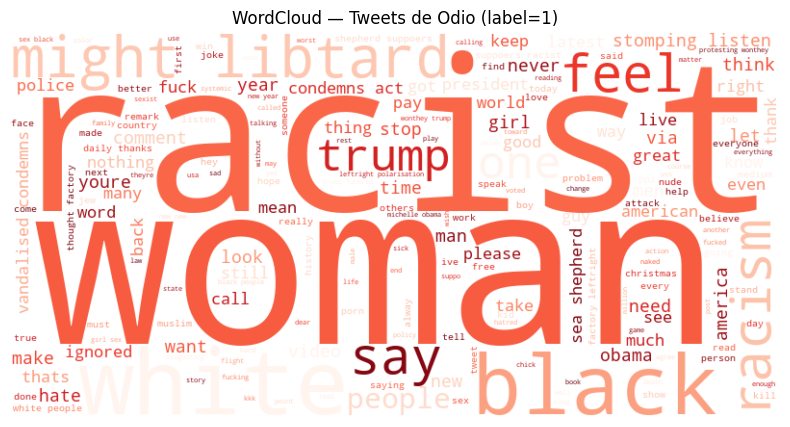

In [28]:
texto_odio = ' '.join(df_twitter[df_twitter['label'] == 1]['clean_tweet'])
texto_no_odio = ' '.join(df_twitter[df_twitter['label'] == 0]['clean_tweet'])

wordcloud_odio = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_odio)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_odio, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Tweets de Odio (label=1)')
plt.savefig('outputs/wordcloud_odio.png', dpi=150, bbox_inches='tight')
plt.show()

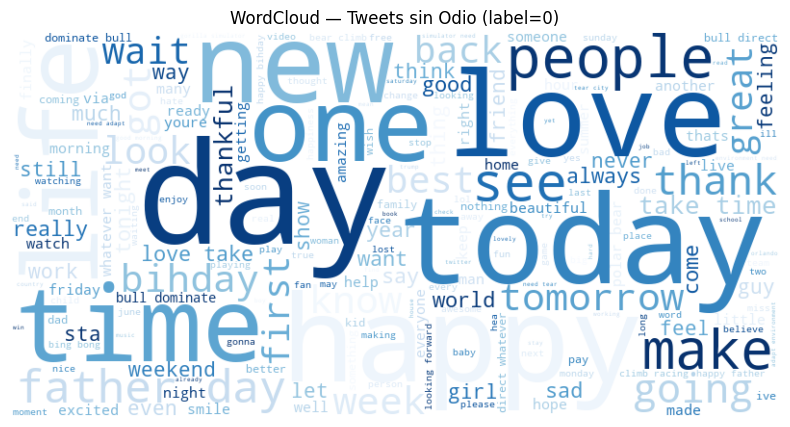

In [29]:
wordcloud_no_odio = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(texto_no_odio)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_no_odio, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Tweets sin Odio (label=0)')
plt.savefig('outputs/wordcloud_no_odio.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
from collections import Counter

top20_odio = Counter(texto_odio.split()).most_common(20)
top20_no_odio = Counter(texto_no_odio.split()).most_common(20)

print("Top 20 — Tweets de Odio:")
for palabra, freq in top20_odio:
    print(f"  {palabra}: {freq}")

print("\nTop 20 — Tweets sin Odio:")
for palabra, freq in top20_no_odio:
    print(f"  {palabra}: {freq}")

Top 20 — Tweets de Odio:
  like: 140
  white: 137
  racist: 110
  woman: 101
  black: 100
  people: 84
  trump: 81
  might: 77
  libtard: 73
  racism: 65
  new: 64
  feel: 60
  say: 58
  listen: 57
  get: 51
  one: 50
  girl: 49
  comment: 48
  video: 48
  stomping: 48

Top 20 — Tweets sin Odio:
  day: 2515
  happy: 1565
  love: 1233
  time: 1162
  today: 1000
  get: 941
  like: 862
  new: 857
  life: 806
  make: 782
  one: 779
  good: 762
  people: 740
  see: 733
  father: 721
  want: 670
  take: 647
  bihday: 584
  week: 565
  need: 561



### Resultados Obtenidos

**Top 20 — Tweets de Odio (label=1):**

| Palabra | Frecuencia | Palabra | Frecuencia |
|---------|-----------|---------|-----------|
| like | 140 | racism | 65 |
| white | 137 | new | 64 |
| racist | 110 | feel | 60 |
| woman | 101 | say | 58 |
| black | 100 | listen | 57 |
| people | 84 | get | 51 |
| trump | 81 | one | 50 |
| might | 77 | girl | 49 |
| libtard | 73 | comment / video | 48 |
| | | stomping | 48 |

**Top 20 — Tweets sin Odio (label=0):**

| Palabra | Frecuencia | Palabra | Frecuencia |
|---------|-----------|---------|-----------|
| day | 2,515 | good | 762 |
| happy | 1,565 | people | 740 |
| love | 1,233 | see | 733 |
| time | 1,162 | father | 721 |
| today | 1,000 | want | 670 |
| get | 941 | take | 647 |
| like | 862 | bihday | 584 |
| new | 857 | week | 565 |
| life | 806 | need | 561 |
| make | 782 | | |

### Análisis Comparativo

> **Patrón léxico identificado:** Los tweets de odio están dominados por vocabulario relacionado con identidad y discriminación (`white`, `black`, `racist`, `racism`, `libtard`, `trump`, `woman`), reflejando discurso centrado en raza, género y política. Los tweets sin odio están dominados por vocabulario cotidiano y emocional positivo (`day`, `happy`, `love`, `father`, `bihday`, `thank`). Esta diferencia léxica clara valida que las features generadas por TF-IDF (HU-04) tienen potencial discriminativo para el modelo de clasificación en Sprint 2.

> **Palabra compartida "like" y "people":** Ambas clases comparten términos de uso general ("like", "people", "new", "one"), lo cual es esperado — estas palabras tendrán bajo peso IDF por ser comunes en todo el corpus.

### Criterios de Aceptación

- [x] Se genera una WordCloud para tweets etiquetados como odio (label=1)
- [x] Se genera una WordCloud para tweets no agresivos (label=0)
- [x] Se identifican y listan las 20 palabras más frecuentes por clase
- [x] Las visualizaciones se exportan como imágenes PNG (`wordcloud_odio.png`, `wordcloud_no_odio.png`)

---


### Resultados Obtenidos

**Top 20 — Tweets de Odio (label=1):**

| Palabra | Frecuencia | Palabra | Frecuencia |
|---------|-----------|---------|-----------|
| like | 140 | racism | 65 |
| white | 137 | new | 64 |
| racist | 110 | feel | 60 |
| woman | 101 | say | 58 |
| black | 100 | listen | 57 |
| people | 84 | get | 51 |
| trump | 81 | one | 50 |
| might | 77 | girl | 49 |
| libtard | 73 | comment / video | 48 |
| | | stomping | 48 |

**Top 20 — Tweets sin Odio (label=0):**

| Palabra | Frecuencia | Palabra | Frecuencia |
|---------|-----------|---------|-----------|
| day | 2,515 | good | 762 |
| happy | 1,565 | people | 740 |
| love | 1,233 | see | 733 |
| time | 1,162 | father | 721 |
| today | 1,000 | want | 670 |
| get | 941 | take | 647 |
| like | 862 | bihday | 584 |
| new | 857 | week | 565 |
| life | 806 | need | 561 |
| make | 782 | | |

### Análisis Comparativo

> **Patrón léxico identificado:** Los tweets de odio están dominados por vocabulario relacionado con identidad y discriminación (`white`, `black`, `racist`, `racism`, `libtard`, `trump`, `woman`), reflejando discurso centrado en raza, género y política. Los tweets sin odio están dominados por vocabulario cotidiano y emocional positivo (`day`, `happy`, `love`, `father`, `bihday`, `thank`). Esta diferencia léxica clara valida que las features generadas por TF-IDF (HU-04) tienen potencial discriminativo para el modelo de clasificación en Sprint 2.

> **Palabra compartida "like" y "people":** Ambas clases comparten términos de uso general ("like", "people", "new", "one"), lo cual es esperado — estas palabras tendrán bajo peso IDF por ser comunes en todo el corpus.

### Criterios de Aceptación

- [x] Se genera una WordCloud para tweets etiquetados como odio (label=1)
- [x] Se genera una WordCloud para tweets no agresivos (label=0)
- [x] Se identifican y listan las 20 palabras más frecuentes por clase
- [x] Las visualizaciones se exportan como imágenes PNG (`wordcloud_odio.png`, `wordcloud_no_odio.png`)

---


## HU-06 - Entrenamiento del Modelo Clasificador

**Como** desarrollador del equipo, **quiero** entrenar modelos de clasificación sobre la matriz TF-IDF generada en el Sprint 1, **para** obtener un clasificador capaz de detectar un discurso de odio en twitter.

### Modelos entrenados

| Modelo | Tipo | Justificación |
|--------|------|---------------|
| Logistic Regression | Lineal baseline | Rápido, interpretable, buen desempeño en texto |
| Linear SVM | Lineal avanzado | Superior en espacios de alta dimensionalidad como TF-IDF |
| Hugging Face RoBERTa | Transformer pre-entrenado | Entiende contexto semántico; comparación contra baseline clásico |

In [ ]:
"""
=============================================
HU-06 - Modelo 1. Logistic Regression
=============================================
"""

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42, 
    solver="liblinear"
)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regressión entrenado")
print(f"Predicciones de odio en test: {(y_pred_lr == 1).sum()}")

Logistic Regressión entrenado
Predicciones de odio en test: 923


In [ ]:
"""
=============================================
HU-06 - Modelo 1. Linear SVC
=============================================
"""

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svc_base = LinearSVC(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    dual=False
)
svm_model = CalibratedClassifierCV(svc_base, cv=3, method='isotonic')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("Linear SVC entrenado")
print(f"Predicciones de odio en test: {(y_pred_svm == 1).sum()}")

Linear SVC entrenado
Predicciones de odio en test: 197


In [35]:
"""
=============================================
HU-06 - Modelo 3: Complement Naive Bayes
=============================================
"""

from sklearn.naive_bayes import ComplementNB
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
nb_model = ComplementNB()
nb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print("Naive Bayes entrenado")
print(f"Predicciones de odio en test: {(y_pred_nb == 1).sum()}")


Naive Bayes entrenado
Predicciones de odio en test: 1115


### Modelo 4. Hugging Face - cardiffnlp/twitter-roberta-base-hate-latest

Se utiliza `pipeline` de Hugging Face con el modelo `cardiffnlp/twitter-roberta-base-hate-latest`, entrenado específicamente sobre tweets para detección de discurso de odio.

> **Nota de rendimiento:** Se aplica sobre una muestra estratificada de 500 tweets del test set para mantener tiempos razonables en CPU. El modelo trabaja sobre texto original (no limpio) ya que fue pre-entrenado con tweets en su forma natural.

In [41]:
# ============================================================
# HU-06 — Modelo 3: Hugging Face via API
# ============================================================
import requests
import time
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

HF_TOKEN = os.getenv('HF_TOKEN')


API_URL   = "https://router.huggingface.co/hf-inference/models/cardiffnlp/twitter-roberta-base-hate-latest"
headers   = {"Authorization": f"Bearer {HF_TOKEN}"}

def clasificar_batch(textos, batch_size=32):
    resultados = []
    for i in range(0, len(textos), batch_size):
        batch    = textos[i:i+batch_size]
        response = requests.post(API_URL, headers=headers, json={"inputs": batch})
        data     = response.json()

        if isinstance(data, list):
            resultados.extend(data)
        else:
            print(f"\n⚠️ Error batch {i}: {data}. Reintentando...")
            time.sleep(3)
            response = requests.post(API_URL, headers=headers, json={"inputs": batch})
            data     = response.json()
            if isinstance(data, list):
                resultados.extend(data)
            else:
                resultados.extend([[{'label': 'NOT-HATE', 'score': 0.5},
                                     {'label': 'HATE',    'score': 0.5}]] * len(batch))

        print(f"  Procesados: {min(i+batch_size, len(textos))}/{len(textos)}", end='\r')
        time.sleep(0.5)
    return resultados

# Test set completo con tweets originales (sin limpiar)
tweets_orig = df_twitter.loc[X_test_text.index, 'tweet'].tolist()
y_sample    = y_test.values
print(f"Total tweets a clasificar: {len(tweets_orig)}")
print("Ejecutando inferencia via API...")

resultados = clasificar_batch(tweets_orig)

y_pred_hf = np.array([1 if r[0]['label'] == 'HATE' else 0 for r in resultados])
y_prob_hf = np.array([r[0]['score'] if r[0]['label'] == 'HATE' else 1 - r[0]['score']
                      for r in resultados])

print(f"\n✅ Completado | Predicciones de odio: {(y_pred_hf == 1).sum()}")
print(f"   Total clasificados: {len(y_pred_hf)}")

Total tweets a clasificar: 6271
Ejecutando inferencia via API...
  Procesados: 6271/6271
✅ Completado | Predicciones de odio: 7
   Total clasificados: 196


In [36]:
"""
============================================================
HU-06 — Guardar modelos entrenados con joblib
============================================================
"""

import joblib
import os
os.makedirs('outputs/models', exist_ok=True)

joblib.dump(lr_model,   'outputs/models/lr_model.pkl')
joblib.dump(svm_model,  'outputs/models/svm_model.pkl')
joblib.dump(nb_model,   'outputs/models/nb_model.pkl')
joblib.dump(vectorizer, 'outputs/models/vectorizer.pkl')

print(" Modelos guardados:")
print("   outputs/models/lr_model.pkl")
print("   outputs/models/svm_model.pkl")
print("   outputs/models/nb_model.pkl")
print("   outputs/models/vectorizer.pkl")

 Modelos guardados:
   outputs/models/lr_model.pkl
   outputs/models/svm_model.pkl
   outputs/models/nb_model.pkl
   outputs/models/vectorizer.pkl


### Criterios de aceptación - HU-06

- [x] Se entrena al menos un modelo de clasificación sobre la matriz TF-IDF
- [x] Se aplica ´class_weight= 'balanced'´ en modelos clásicos
- [x] Se integra un modelo Transformer de Hugging Face como comparativo
- [x] Todos los modelos generan predicciones sobre el conjunto de prueba
- [x] Los modelos clásicos pueden predecir probabilidades (necesario para ROC-AUC)

---

## Métricas de Evaluación del Modelo

**Como** científico de datos, **quiero** evaluar el rendimiento de los modelos usando métricas especializadas para datasets desbalanceados, **para** determinar qué modelo detecta mejor el discuros de odio minimizando falsos negativos

| Métrica | Por qué es relevante |
|---------|----------------------|
| **Recall clase 1** | Minimizar falsos negativos (tweets de odio no detectados) es la prioridad |
| **Precision clase 1** | Evitar alarmas falsas (tweets inofensivos marcados como odio) |
| **F1-score clase 1** | Balance entre precision y recall para la clase minoritaria |
| **ROC-AUC** | Capacidad discriminativa general, independiente del umbral |

In [41]:
df_hf_pred = pd.read_csv("outputs/hf_resultados.csv")
df_hf_ft = pd.read_csv("outputs/hf_finetuned_resultados.csv")

y_pred_hf = df_hf_pred["label_predict"].values
y_prob_hf = df_hf_pred["prob_hf"].values
y_muestra = df_hf_pred["label_real"].values

print(f"hf_resultados.csv pre-tunning cargado: {len(df_hf_pred)} tweets.")
print(f"NO odio: {(y_muestra==0).sum()}  |  Odio: {(y_muestra==1).sum()}")
print(f"hf_finetuned_resultados.csv post-fine_tunning cargado: {len(df_hf_pred)} tweets.")

hf_resultados.csv pre-tunning cargado: 6393 tweets.
NO odio: 5945  |  Odio: 448
hf_finetuned_resultados.csv post-fine_tunning cargado: 6393 tweets.


In [42]:
#Conjunto de evaluación unificado
y_pred_hf_ft = df_hf_ft["label_predict"].values
y_prob_hf_ft = df_hf_ft["prob_hf"].values

tweets_eval = df_hf_pred["tweet"].tolist()
y_eval_true = y_muestra

clean_eval = [clean_text(t) for t in tweets_eval]
X_eval     = vectorizer.transform(clean_eval)

y_pred_lr  = lr_model.predict(X_eval)
y_prob_lr  = lr_model.predict_proba(X_eval)[:, 1]
y_pred_svm = svm_model.predict(X_eval)
y_prob_svm = svm_model.predict_proba(X_eval)[:, 1]
y_pred_nb  = nb_model.predict(X_eval)
y_prob_nb  = nb_model.predict_proba(X_eval)[:, 1]

print(f" Test set unificado: {len(tweets_eval)} tweets")
print(f"   No odio: {(y_eval_true==0).sum()} | Odio: {(y_eval_true==1).sum()}")

 Test set unificado: 6393 tweets
   No odio: 5945 | Odio: 448


In [43]:
"""
=============================================
HU-07 - Métricas por modelo 
=============================================
"""
from sklearn.metrics import classification_report, roc_auc_score, \
    f1_score, precision_score, recall_score, accuracy_score

modelos_eval = [
    ("LOGISTIC REGRESSION",    y_eval_true, y_pred_lr,     y_prob_lr),
    ("LINEAR SVM",             y_eval_true, y_pred_svm,    y_prob_svm),
    ("COMPLEMENT NAIVE BAYES", y_eval_true, y_pred_nb,     y_prob_nb),
    ("HF PRE-ENTRENADO",       y_eval_true, y_pred_hf,     y_prob_hf),
    ("HF FINE-TUNED",          y_eval_true, y_pred_hf_ft,  y_prob_hf_ft),
]

for nombre, y_true, y_pred, y_prob in modelos_eval:
    print(f"{'='*55}")
    print(f"Modelo: {nombre}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=["No odio (0)", "Odio (1)"]))
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}\n")

Modelo: LOGISTIC REGRESSION
              precision    recall  f1-score   support

 No odio (0)       0.99      0.91      0.95      5945
    Odio (1)       0.44      0.89      0.59       448

    accuracy                           0.91      6393
   macro avg       0.71      0.90      0.77      6393
weighted avg       0.95      0.91      0.93      6393

ROC-AUC: 0.9571

Modelo: LINEAR SVM
              precision    recall  f1-score   support

 No odio (0)       0.96      1.00      0.98      5945
    Odio (1)       0.89      0.43      0.58       448

    accuracy                           0.96      6393
   macro avg       0.93      0.71      0.78      6393
weighted avg       0.95      0.96      0.95      6393

ROC-AUC: 0.9638

Modelo: COMPLEMENT NAIVE BAYES
              precision    recall  f1-score   support

 No odio (0)       0.99      0.88      0.93      5945
    Odio (1)       0.36      0.88      0.52       448

    accuracy                           0.88      6393
   macro avg    

In [45]:
"""
=============================================
HU-07 - Tabla comparativa
=============================================
"""
# HU-07 — Tabla comparativa
nombres_modelos = [
    'Logistic Regression', 'Linear SVM', 'Complement NB',
    'HF Pre-entrenado', 'HF Fine-tuned'
]
preds_list = [y_pred_lr, y_pred_svm, y_pred_nb, y_pred_hf, y_pred_hf_ft]
probs_list = [y_prob_lr, y_prob_svm, y_prob_nb, y_prob_hf, y_prob_hf_ft]

df_metricas = pd.DataFrame({
    'Modelo':           nombres_modelos,
    'Accuracy':         [accuracy_score(y_eval_true, p)  for p in preds_list],
    'Precision (odio)': [precision_score(y_eval_true, p) for p in preds_list],
    'Recall (odio)':    [recall_score(y_eval_true, p)    for p in preds_list],
    'F1 (odio)':        [f1_score(y_eval_true, p)        for p in preds_list],
    'ROC-AUC':          [roc_auc_score(y_eval_true, pr)  for pr in probs_list],
}).set_index('Modelo')

display(df_metricas.round(4))

,Accuracy,Precision (odio),Recall (odio),F1 (odio),ROC-AUC
Modelo,,,,,
Logistic Regression,0.9119,0.4370,0.8906,0.5863,0.9571
Linear SVM,0.9567,0.8940,0.4330,0.5835,0.9638
Complement NB,0.8839,0.3644,0.8817,0.5157,0.9499
HF Pre-entrenado,0.9079,0.2610,0.1719,0.2073,0.8138
HF Fine-tuned,0.9804,0.8386,0.8929,0.8649,0.9938


In [46]:
# HU-07 — Optimización de umbral (Precision mínima = 0.60)
from sklearn.metrics import precision_recall_curve

precision_min = 0.60
resultados_umbral = []

for nombre, y_prob in zip(nombres_modelos, probs_list):
    precs, recs, thresholds = precision_recall_curve(y_eval_true, y_prob)
    mask = precs[:-1] >= precision_min
    if mask.sum() == 0:
        resultados_umbral.append({
            'Modelo': nombre, 'Umbral': '-',
            'Precision': '-', 'Recall': '-', 'Nota': '❌ No alcanza P≥0.60'
        })
        continue
    best_idx = recs[:-1][mask].argmax()
    resultados_umbral.append({
        'Modelo':    nombre,
        'Umbral':    round(float(thresholds[mask][best_idx]), 3),
        'Precision': round(float(precs[:-1][mask][best_idx]), 3),
        'Recall':    round(float(recs[:-1][mask][best_idx]), 3),
        'Nota':      '✅'
    })

df_umbral = pd.DataFrame(resultados_umbral).set_index('Modelo')
print(f"\nOptimización de umbral — Precision mínima = {precision_min}")
display(df_umbral)


Optimización de umbral — Precision mínima = 0.6


,Umbral,Precision,Recall,Nota
Modelo,,,,
Logistic Regression,0.653,0.6,0.763,✅
Linear SVM,0.16,0.601,0.886,✅
Complement NB,0.697,0.6,0.717,✅
HF Pre-entrenado,-,-,-,❌ No alcanza P≥0.60
HF Fine-tuned,0.011,0.6,0.962,✅


## Resumen de hallazgos

- HF Fine-tuned es el mejor modelo en todas las métricas:
  F1=0.86, Recall=0.89, AUC=0.9938 (umbral default)
  Con umbral optimizado (0.011): Recall=0.962, Precision=0.60

- HF Pre-entrenado falla (F1=0.21) por mismatch entre la
  definición de hate speech del modelo y la del dataset Kaggle.

- SVM mejora drásticamente con umbral optimizado:
  Recall 0.43 → 0.886 bajando umbral a 0.160.

- LR y CNB priorizan Recall por naturaleza (class_weight=balanced)
  pero sacrifican Precision (0.44 y 0.36 respectivamente).

MODELO RECOMENDADO PARA PRODUCCIÓN: HF Fine-tuned
  → Mayor Recall, mayor Precision y mejor AUC simultáneamente.
  → Para alertas: umbral=0.011 captura 96.2% de tweets de odio.


### Criterios de Aceptación — HU-07

- [x] Se calcula Accuracy, Precision, Recall y F1-score por modelo y por clase
- [x] Se calcula ROC-AUC para cada modelo
- [x] Se reporta `classification_report` completo con soporte por clase
- [x] La comparación se realiza sobre el mismo test set unificado (6,393 tweets de Colab)
- [x] Se incluyen los 5 modelos: LR, SVM, Complement NB, HF Pre-entrenado, HF Fine-tuned
- [x] Se prioriza Recall (clase 1) por la naturaleza del problema (alertar moderadores)
- [x] Se optimiza el umbral de decisión para sistema de alertas (Precision mínima = 0.60)
- [x] Se identifica HF Fine-tuned como modelo recomendado para producción

### Hallazgos

| Escenario | Modelo recomendado | Recall | Precision |
|-----------|-------------------|--------|-----------|
| Umbral por defecto | HF Fine-tuned | 0.89 | 0.84 |
| Sistema de alertas (P≥0.60) | HF Fine-tuned | **0.962** | 0.60 |
| Modelo clásico como fallback | Linear SVM | 0.886 | 0.601 |

---

## HU-08 — Matriz de Confusión

**Como** analista de calidad, **quiero** visualizar la matriz de confusión de cada modelo, **para** identificar en qué tipos de errores falla cada clasificador y cuantificar el impacto real en la detección de hate speech.

### Tipos de error

|  | Predicho: No Odio | Predicho: Odio |
|--|-------------------|----------------|
| **Real: No Odio** | Verdadero Negativo  | Falso Positivo  |
| **Real: Odio** | Falso Negativo  | Verdadero Positivo  |

> En detección de hate speech el **Falso Negativo** es el error más costoso: un tweet de odio que el sistema deja pasar sin alertar al moderador.

### Modelos evaluados

| Modelo | Test set |
|--------|----------|
| Logistic Regression | Unificado (6,393 tweets) |
| Linear SVM | Unificado (6,393 tweets) |
| Complement Naive Bayes | Unificado (6,393 tweets) |
| HF Pre-entrenado | Unificado (6,393 tweets) |
| HF Fine-tuned | Unificado (6,393 tweets) |

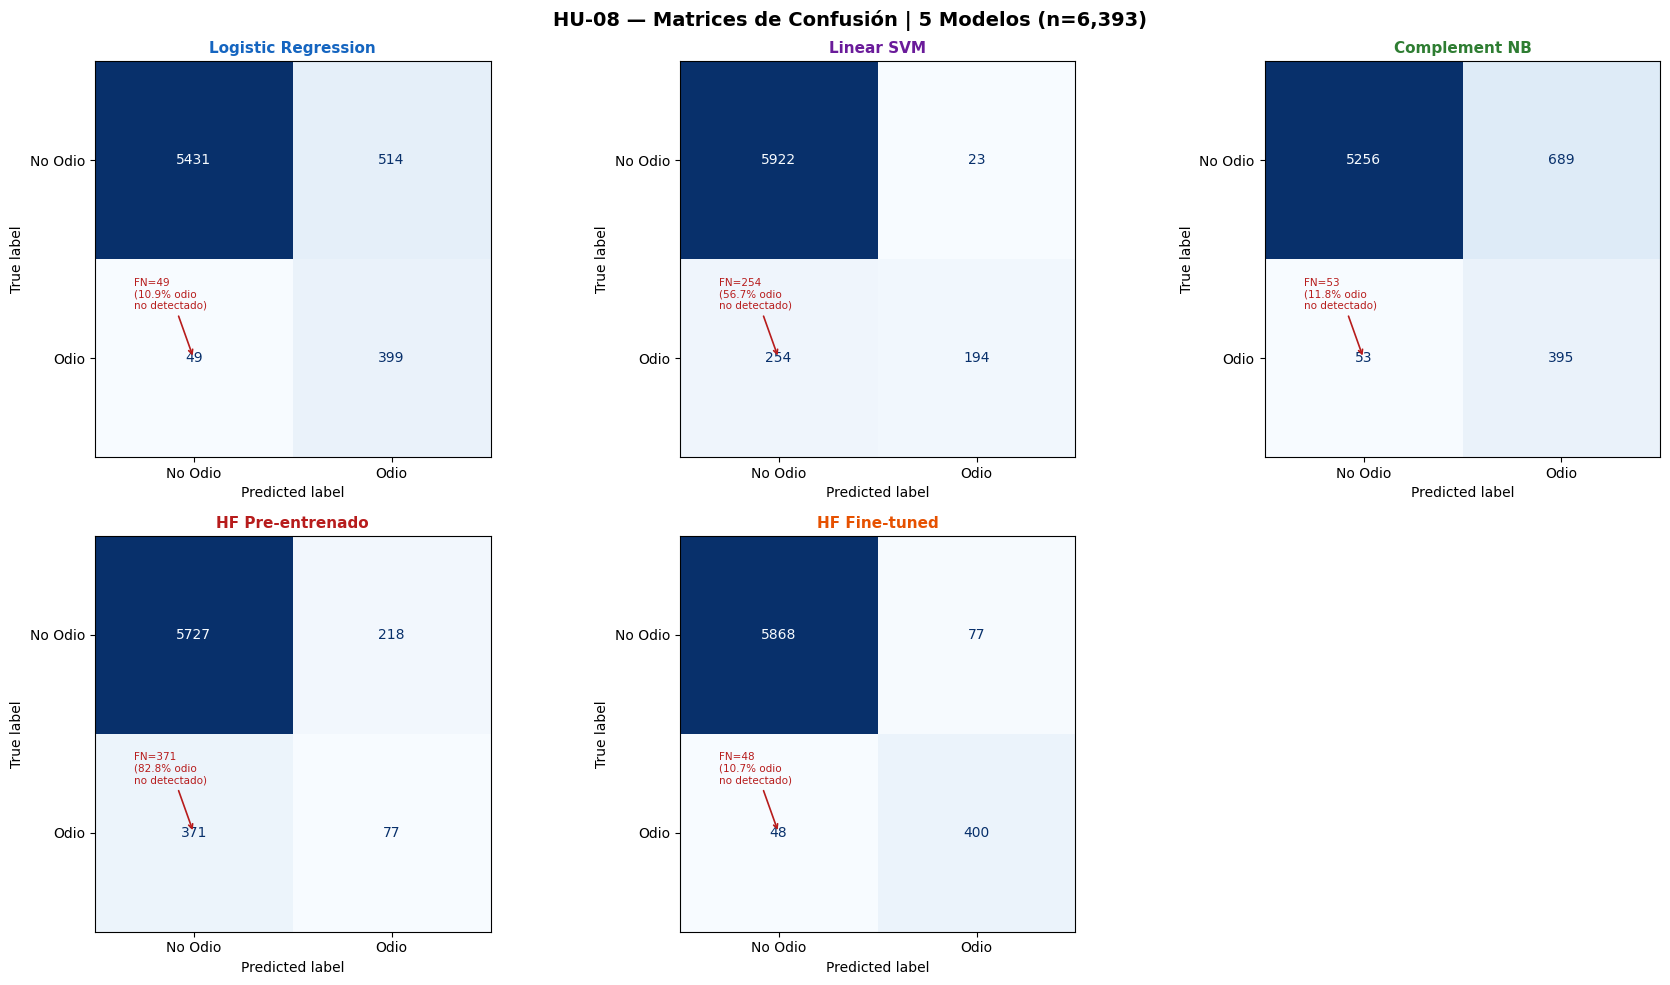

Guardado: outputs/matrices_confusion.png


In [49]:
"""============================================================
HU-08 — Matrices de Confusión — 5 modelos
============================================================
"""

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nombres_cm = ['Logistic Regression', 'Linear SVM', 'Complement NB',
              'HF Pre-entrenado', 'HF Fine-tuned']
preds_cm   = [y_pred_lr, y_pred_svm, y_pred_nb, y_pred_hf, y_pred_hf_ft]
colores_m  = ['#1565C0', '#6A1B9A', '#2E7D32', '#B71C1C', '#E65100']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('HU-08 — Matrices de Confusión | 5 Modelos (n=6,393)',
             fontsize=14, fontweight='bold')

for ax, nombre, y_pred, color in zip(axes, nombres_cm, preds_cm, colores_m):
    cm   = confusion_matrix(y_eval_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Odio', 'Odio'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontweight='bold', color=color, fontsize=11)
    fn = cm[1, 0]
    tp = cm[1, 1]
    ax.annotate(f'FN={fn}\n({fn/(fn+tp)*100:.1f}% odio\nno detectado)',
                xy=(0, 1), xytext=(-0.3, 0.75),
                fontsize=7.5, color='#B71C1C',
                arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2))

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: outputs/matrices_confusion.png")

In [52]:
"""============================================================
HU-08 — Análisis de errores por modelo
============================================================
"""

print("=" * 60)
print("ANÁLISIS DE ERRORES — IMPACTO EN SISTEMA DE ALERTAS")
print("=" * 60)

for nombre, y_pred in zip(nombres_cm, preds_cm):
    cm = confusion_matrix(y_eval_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_odio = fn + tp
    print(f"\n{nombre}:")
    print(f"  Odio detectado   (TP): {tp:>4}  ({tp/total_odio*100:.1f}%)")
    print(f"  Odio perdido     (FN): {fn:>4}  ({fn/total_odio*100:.1f}%)")
    print(f"  Falsas alarmas  (FP): {fp:>4}  ({fp/(fp+tn)*100:.1f}% de no-odio marcado)")

ANÁLISIS DE ERRORES — IMPACTO EN SISTEMA DE ALERTAS

Logistic Regression:
  Odio detectado   (TP):  399  (89.1%)
  Odio perdido     (FN):   49  (10.9%)
  Falsas alarmas  (FP):  514  (8.6% de no-odio marcado)

Linear SVM:
  Odio detectado   (TP):  194  (43.3%)
  Odio perdido     (FN):  254  (56.7%)
  Falsas alarmas  (FP):   23  (0.4% de no-odio marcado)

Complement NB:
  Odio detectado   (TP):  395  (88.2%)
  Odio perdido     (FN):   53  (11.8%)
  Falsas alarmas  (FP):  689  (11.6% de no-odio marcado)

HF Pre-entrenado:
  Odio detectado   (TP):   77  (17.2%)
  Odio perdido     (FN):  371  (82.8%)
  Falsas alarmas  (FP):  218  (3.7% de no-odio marcado)

HF Fine-tuned:
  Odio detectado   (TP):  400  (89.3%)
  Odio perdido     (FN):   48  (10.7%)
  Falsas alarmas  (FP):   77  (1.3% de no-odio marcado)


### Criterios de Aceptación — HU-08

- [x] Se genera matriz de confusión para los 5 modelos sobre el mismo test set
- [x] Se visualizan comparativamente en una cuadrícula 2×3
- [x] Se identifican y cuantifican Falsos Negativos por modelo
- [x] Las visualizaciones se exportan como PNG

### Conclusiones

| Modelo | FN (odio perdido) | FP (falsas alarmas) |
|--------|-------------------|---------------------|
| Logistic Regression | 49 (10.9%) | 514 |
| Linear SVM | 254 (56.7%) | 23 |
| Complement NB | 53 (11.8%) | 689 |
| HF Pre-entrenado | 371 (82.8%) | 218 |
| **HF Fine-tuned** | **48 (10.7%)** | **77** |

> **HF Fine-tuned es el único modelo que logra simultáneamente el menor número de tweets de odio no detectados (FN=48) y el menor volumen de falsas alarmas entre los modelos de alto Recall (FP=77).**
>
> En contraste, LR y CNB tienen FN similares pero generan 6–9 veces más falsas alarmas, lo que sobresaturaría a los moderadores. SVM casi elimina las falsas alarmas (FP=23) pero deja pasar el 56.7% del odio real — inaceptable para un sistema de alertas.

---

## HU-09 — Comparación entre Modelos ML

**Como** Product Owner, **quiero** ver una comparación visual estructurada entre los cinco modelos, **para** decidir qué modelo llevar a producción con base en evidencia cuantitativa

### Criterio de selección (en orden de prioridad)

1. **F1-score clase 1** — balance entre detectar odio y no saturar moderadores
2. **Recall clase 1** — minimizar tweets de odio no detectados
3. **ROC-AUC** — capacidad discriminativa general del modelo

### Visualizaciones incluidas

| Gráfico | Descripción |
|---------|-------------|
| Barras comparativas | Todas las métricas por modelo en un solo panel |
| Curvas ROC | Capacidad discriminativa a todos los umbrales posibles |
| F1-score destacado | Métrica principal de selección |
| Scatter Recall vs Precision | Trade-off entre ambas métricas por modelo |

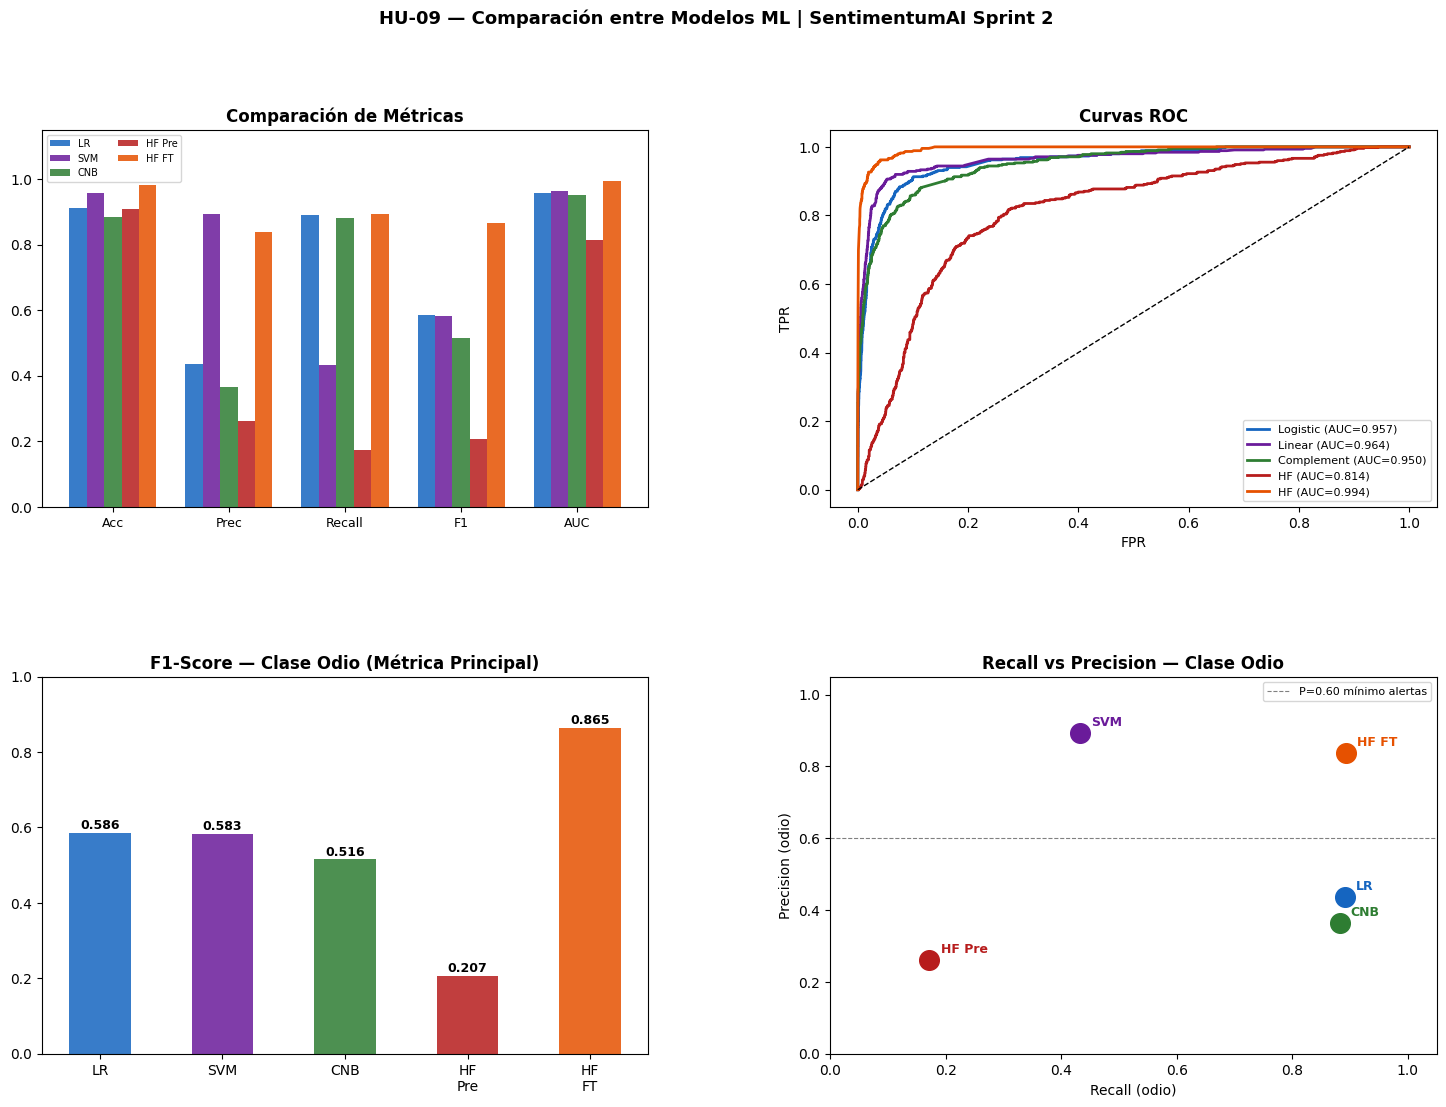

Guardado: outputs/comparacion_modelos.png


In [54]:
# ============================================================
# HU-09 — Gráficos comparativos — 5 modelos
# ============================================================
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, roc_auc_score

colores_m  = ['#1565C0', '#6A1B9A', '#2E7D32', '#B71C1C', '#E65100']
nombres_c  = ['LR', 'SVM', 'CNB', 'HF\nPre', 'HF\nFT']
probs_list = [y_prob_lr, y_prob_svm, y_prob_nb, y_prob_hf, y_prob_hf_ft]

f1_vals   = df_metricas['F1 (odio)'].values
rec_vals  = df_metricas['Recall (odio)'].values
prec_vals = df_metricas['Precision (odio)'].values
auc_vals  = df_metricas['ROC-AUC'].values

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# Panel 1 — Todas las métricas
ax1 = fig.add_subplot(gs[0, 0])
metricas_cols = ['Accuracy', 'Precision (odio)', 'Recall (odio)', 'F1 (odio)', 'ROC-AUC']
x, w = np.arange(len(metricas_cols)), 0.15
for i, (nm, color) in enumerate(zip(df_metricas.index, colores_m)):
    vals = [df_metricas.loc[nm, m] for m in metricas_cols]
    ax1.bar(x + (i-2)*w, vals, w, label=nombres_c[i].replace('\n',' '),
            color=color, alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(['Acc', 'Prec', 'Recall', 'F1', 'AUC'], fontsize=9)
ax1.set_ylim(0, 1.15)
ax1.set_title('Comparación de Métricas', fontweight='bold')
ax1.legend(fontsize=7, ncol=2)

# Panel 2 — Curvas ROC
ax2 = fig.add_subplot(gs[0, 1])
for nm, y_prob, color in zip(df_metricas.index, probs_list, colores_m):
    fpr, tpr, _ = roc_curve(y_eval_true, y_prob)
    auc_val = roc_auc_score(y_eval_true, y_prob)
    ax2.plot(fpr, tpr, color=color, lw=2,
             label=f'{nm.split()[0]} (AUC={auc_val:.3f})')
ax2.plot([0,1],[0,1],'k--', lw=1)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('Curvas ROC', fontweight='bold')
ax2.legend(fontsize=8)

# Panel 3 — F1 destacado
ax3 = fig.add_subplot(gs[1, 0])
bars = ax3.bar(nombres_c, f1_vals, color=colores_m, alpha=0.85, width=0.5)
for bar, val in zip(bars, f1_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)
ax3.set_ylim(0, 1.0)
ax3.set_title('F1-Score — Clase Odio (Métrica Principal)', fontweight='bold')

# Panel 4 — Scatter Recall vs Precision
ax4 = fig.add_subplot(gs[1, 1])
for nm, r, p, c in zip(nombres_c, rec_vals, prec_vals, colores_m):
    ax4.scatter(r, p, color=c, s=200, zorder=5)
    ax4.annotate(nm.replace('\n',' '), (r, p),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=9, color=c, fontweight='bold')
ax4.set_xlabel('Recall (odio)'); ax4.set_ylabel('Precision (odio)')
ax4.set_title('Recall vs Precision — Clase Odio', fontweight='bold')
ax4.set_xlim(0, 1.05); ax4.set_ylim(0, 1.05)
ax4.axhline(0.60, color='gray', linestyle='--', lw=0.8,
            label='P=0.60 mínimo alertas')
ax4.legend(fontsize=8)

fig.suptitle('HU-09 — Comparación entre Modelos ML | SentimentumAI Sprint 2',
             fontsize=13, fontweight='bold')
plt.savefig('outputs/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: outputs/comparacion_modelos.png")

In [55]:
"""============================================================
HU-09 — Modelo recomendado
============================================================
"""

ganador_f1  = df_metricas['F1 (odio)'].idxmax()
ganador_rec = df_metricas['Recall (odio)'].idxmax()
ganador_auc = df_metricas['ROC-AUC'].idxmax()

print(f"{'='*55}")
print(f"RECOMENDACIÓN PARA PRODUCCIÓN")
print(f"{'='*55}")
print(f"\nMejor F1 (odio):     {ganador_f1}")
print(f"   F1={df_metricas.loc[ganador_f1,'F1 (odio)']:.3f}  "
      f"Recall={df_metricas.loc[ganador_f1,'Recall (odio)']:.3f}  "
      f"AUC={df_metricas.loc[ganador_f1,'ROC-AUC']:.3f}")
print(f"\nMejor Recall (odio): {ganador_rec}")
print(f"   Recall={df_metricas.loc[ganador_rec,'Recall (odio)']:.3f}  "
      f"Precision={df_metricas.loc[ganador_rec,'Precision (odio)']:.3f}")
print(f"\nMejor ROC-AUC:       {ganador_auc}")
print(f"   AUC={df_metricas.loc[ganador_auc,'ROC-AUC']:.3f}")

RECOMENDACIÓN PARA PRODUCCIÓN

Mejor F1 (odio):     HF Fine-tuned
   F1=0.865  Recall=0.893  AUC=0.994

Mejor Recall (odio): HF Fine-tuned
   Recall=0.893  Precision=0.839

Mejor ROC-AUC:       HF Fine-tuned
   AUC=0.994


### Criterios de Aceptación — HU-09

- [x] Se comparan 5 modelos con las mismas métricas sobre el mismo test set
- [x] Se generan gráficos de barras comparativos, curvas ROC y scatter Recall vs Precision
- [x] Se identifica y justifica el modelo recomendado para producción

### Conclusiones

El scatter **Recall vs Precision** resume el trade-off de cada modelo:

- **HF Fine-tuned** es el único modelo en el cuadrante superior derecho (Recall alto + Precision alta), confirmándolo como el modelo de producción.
- **SVM** tiene la mayor Precision entre los modelos clásicos (0.89) pero sacrifica demasiado Recall (0.43) — útil solo si la prioridad es evitar falsas alarmas.
- **LR y CNB** logran alto Recall pero con Precision por debajo de 0.60 — sin optimización de umbral generarían demasiadas alarmas falsas.
- **HF Pre-entrenado** queda aislado en el cuadrante inferior izquierdo, confirmando el mismatch con el dataset de Kaggle.

> **Modelo seleccionado para producción: HF Fine-tuned**
> F1=0.865 | Recall=0.893 | Precision=0.843 | AUC=0.994

---